This notebook demonstrates how to use the PyGMT plotting maps in GPlately.
The PyGMT integration is still in early stage, and we are working on adding more features to it.
Please open GitHub issues and let us know how we could enhance the PyGMT integration.
We are grateful for your feedbacks. Thank you.
https://github.com/GPlates/gplately/issues

⚠️ This notebook is generated from plot_map_with_pygmt.py using the command `jupytext --to notebook Notebooks/Examples/plot_map_with_pygmt.py -o Notebooks/Examples/plot_map_with_pygmt.ipynb`.
If you need to commit changes to this notebook to the GPlately repository, make your edits in plot_map_with_pygmt.py and a GitHub workflow will regenerate this Jupyter Notebook file automatically.
The reason that a .py file is used is to allow for easier version control and collaboration. And it is also more Copilot and code auto-formatting friendly.

/Users/mchin/workspace/gplately.git/gplately/plot.py:1849: UserWarning: The 'plot_ridges' function has been changed since GPlately 1.3.0. You need to check your workflow to make sure the new 'plot_ridges' function still suits your purpose. In earlier releases of GPlately, we used an algorithm to identify the 'ridges' and 'transforms' within the gpml:MidOceanRidge features. Unfortunately, the algorithm did not work very well. So we have removed the algorithm and now the 'plot_ridges' function plots all the features which are labelled as gpml:MidOceanRidge in the reconstruction model.
/Users/mchin/workspace/gplately.git/gplately/decorators.py:67: UserWarning: The 'plot_transforms' function has been changed since GPlately 1.3.0. You need to check your workflow to make sure the new 'plot_transforms' function still suits your purpose. In earlier releases of GPlately, we used an algorithm to identify the 'ridges' and 'transforms' within the gpml:MidOceanRidge features. Unfortunately, the alg

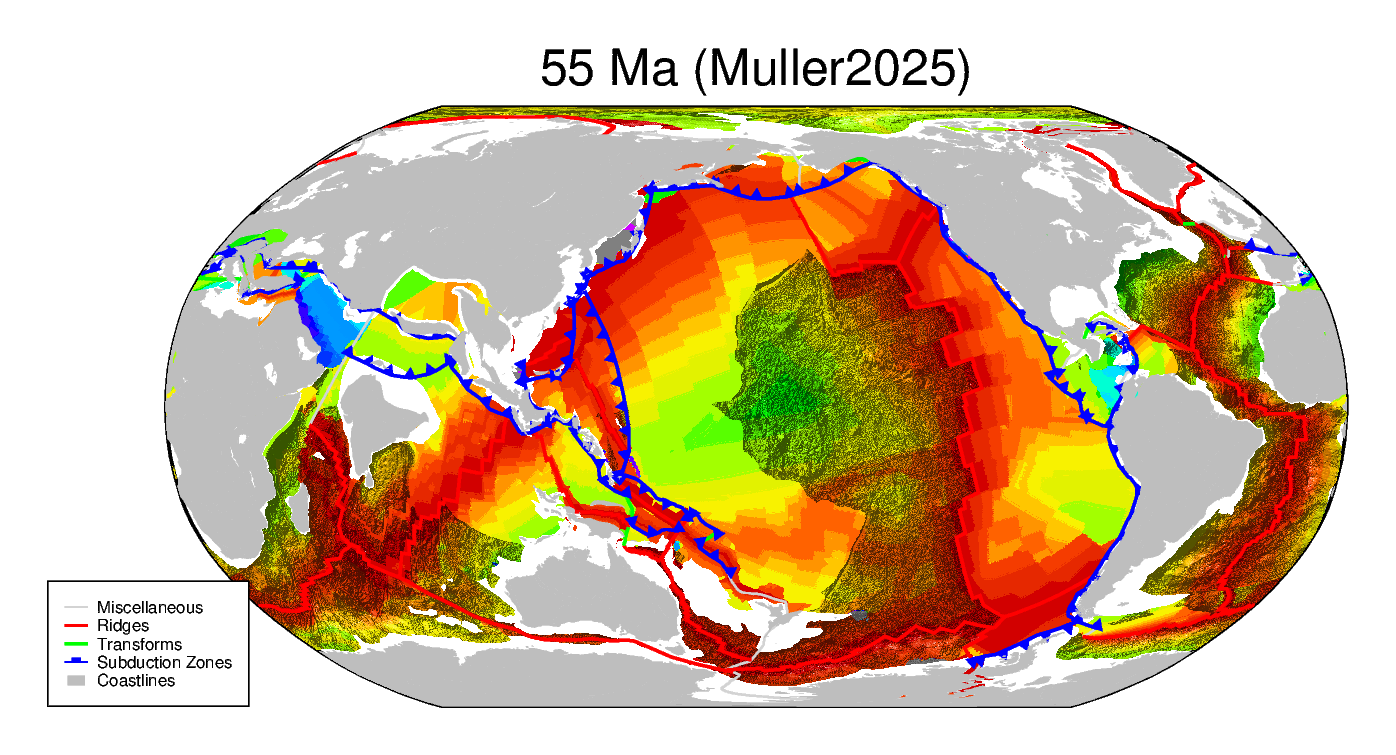

The map has been saved to test-pygmt-plot.pdf.


In [1]:
# pyright: reportMissingImports=false
import os
import pygmt
from gplately.auxiliary import get_gplot, get_pygmt_basemap_figure
from gplately.mapping.pygmt_plot import PygmtPlotEngine
from gplately import Raster
from plate_model_manager import PresentDayRasterManager

if __name__ == "__main__":
    reconstruction_time = 55
    # tell PlotTopologies object to use the PygmtPlotEngine
    gplot = get_gplot(
        model="Muller2025",
        model_repo_dir="plate-model-repo",
        time=reconstruction_time,
        plot_engine=PygmtPlotEngine(),
    )
    # you need to know how to specify projection and region in GMT way
    fig = get_pygmt_basemap_figure(projection="N180/10c", region="d")

    # reconstruct the topography grid for the specified reconstruction time,
    # and use it to create an illumination grid for shading
    data_dir = "./unittest-data"
    topo_file = PresentDayRasterManager(data_dir=data_dir).get_raster("topography")
    topo_grid = Raster(
        data=topo_file, plate_reconstruction=gplot.plate_reconstruction
    ).reconstruct(time=reconstruction_time)

    illumination = pygmt.grdgradient(grid=topo_grid.to_dataarray(), radiance=[315, 45])
    # print(illumination)

    # download age grid CPT file from https://raw.githubusercontent.com/GPlates/gplately/refs/heads/master/tests-dir/unittest/create-age-grids-video/agegrid.cpt
    cpt_file = f"{data_dir}/agegrid.cpt"
    if not os.path.isfile(cpt_file):
        import urllib.request

        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/GPlates/gplately/refs/heads/master/tests-dir/unittest/create-age-grids-video/agegrid.cpt",
            cpt_file,
        )

    gplot.plot_grid(
        fig,
        "AgeGrids",
        cmap=cpt_file,
        nan_transparent=True,
        # shading=True,
        # shading="+a315+ne0.6",
        shading=illumination,
    )

    # now you can plot some features with the PlotTopologies object
    gplot.plot_all_topological_sections(
        fig,
        plot_subduction_teeth=True,
        other_kwargs={
            "color": "lightgrey",
            "linewidth": 0.5,
            "gmtlabel": "Miscellaneous",
        },
        ridge_kwargs={"color": "red", "linewidth": 0.7, "gmtlabel": "Ridges"},
        transform_kwargs={"color": "green", "linewidth": 0.7, "gmtlabel": "Transforms"},
        trench_kwargs={
            "color": "blue",
            "linewidth": 0.7,
            "gmtlabel": "Subduction Zones",
        },
    )
    gplot.plot_coastlines(
        fig,
        edgecolor="none",
        facecolor="gray",
        linewidth=0.1,
        central_meridian=180,
        gmtlabel="Coastlines",
    )

    try:
        # plotting velocities has not been implemented in PygmtPlotEngine yet.
        gplot.plot_plate_motion_vectors(fig)
    except NotImplementedError as e:
        # print(e)
        pass

    # use pygmt directly to plot title and legend
    fig.text(
        text=f"{reconstruction_time} Ma (Muller2025)",
        position="TC",
        no_clip=True,
        font="12p,Helvetica,black",
        offset="j0/-0.5c",
    )
    with pygmt.config(FONT_ANNOT_PRIMARY=4):
        fig.legend(position="jBL+o-1.0/0", box="+gwhite+p0.25p")

    fig.show(width=1200, crop="+m0.4c")

    out_f = "test-pygmt-plot.pdf"
    fig.savefig(out_f, crop="+m0.4c")
    print(f"The map has been saved to {out_f}.")